# Introduction to Pandas

A practical introduction to creating, loading, cleaning and exporting data with pandas.


## Goal

By the end of this notebook, I should be able to work with common CSV and Excel files using a clear pandas workflow.


## 1. Setup

All files used below come from the Day 1 practical folder.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("day_1/Pracs")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

## 2. Create a DataFrame

A Series holds one column, while a DataFrame holds a full table.


In [2]:
brands = ["Galxboy", "Bathu", "Drip", "MaXhosa Africa", "Tshepo Jeans"]
pd.Series(brands, name="South African brands")

0           Galxboy
1             Bathu
2              Drip
3    MaXhosa Africa
4      Tshepo Jeans
Name: South African brands, dtype: object

In [3]:
brand_data = [
    {"Brand": "Galxboy", "Year Founded": 2008, "Founder": "Thatiso Dube"},
    {"Brand": "Bathu", "Year Founded": 2015, "Founder": "Theo Baloyi"},
    {"Brand": "Drip", "Year Founded": 2019, "Founder": "Lekau Sehoana"},
]
brands_df = pd.DataFrame(brand_data)
brands_df

,Brand,Year Founded,Founder
0,Galxboy,2008,Thatiso Dube
1,Bathu,2015,Theo Baloyi
2,Drip,2019,Lekau Sehoana


### Select values

Use a column name for a Series and `.loc` when a row condition is clearer than a row number.


In [4]:
brands_df["Founder"]

0     Thatiso Dube
1      Theo Baloyi
2    Lekau Sehoana
Name: Founder, dtype: object

In [5]:
brands_df.loc[brands_df["Brand"] == "Drip", "Founder"].iloc[0]

'Lekau Sehoana'

## 3. Load external data


### CSV file


In [6]:
loans = pd.read_csv(DATA_DIR / "sa_loan_eligibility_data.csv")
print(f"Shape: {loans.shape}")
loans.head()

Shape: (100, 9)


,Full_Name,Province,Age,Income,Employment_Status,Credit_Score,Home_Owner,Has_Debt,Loan_Approved
0,Ayanda Van Wyk,Eastern Cape,61,16127,Unemployed,407,Yes,No,No
1,Thabo Mahlangu,North West,21,20091,Self-employed,690,No,Yes,No
2,Sipho Naidoo,KwaZulu-Natal,29,64532,Self-employed,343,No,No,No
3,Lerato Mokoena,Mpumalanga,43,49062,Employed,645,No,No,Yes
4,Thabo Dlamini,KwaZulu-Natal,25,6120,Unemployed,434,Yes,No,No


### Excel file


In [7]:
loans_excel = pd.read_excel(DATA_DIR / "sa_loan_eligibility_data.xlsx")
loans_excel.head()

,Full_Name,Province,Age,Income,Employment_Status,Credit_Score,Home_Owner,Has_Debt,Loan_Approved
0,Ayanda Van Wyk,Eastern Cape,61,16127,Unemployed,407,Yes,No,No
1,Thabo Mahlangu,North West,21,20091,Self-employed,690,No,Yes,No
2,Sipho Naidoo,KwaZulu-Natal,29,64532,Self-employed,343,No,No,No
3,Lerato Mokoena,Mpumalanga,43,49062,Employed,645,No,No,Yes
4,Thabo Dlamini,KwaZulu-Natal,25,6120,Unemployed,434,Yes,No,No


## 4. Handle less tidy files


### Add missing headers

`header=None` tells pandas that the first row is data, not a heading.


In [8]:
column_names = ["Full Name", "Province", "Age", "Income", "Employment Status",
                "Credit Score", "Home Owner", "Has Debt", "Loan Approved"]

no_headers = pd.read_excel(DATA_DIR / "no_headers.xlsx", header=None, names=column_names)
no_headers.head()

,Full Name,Province,Age,Income,Employment Status,Credit Score,Home Owner,Has Debt,Loan Approved
0,Ayanda Van Wyk,Eastern Cape,61,16127,Unemployed,407,Yes,No,No
1,Thabo Mahlangu,North West,21,20091,Self-employed,690,No,Yes,No
2,Sipho Naidoo,KwaZulu-Natal,29,64532,Self-employed,343,No,No,No
3,Lerato Mokoena,Mpumalanga,43,49062,Employed,645,No,No,Yes
4,Thabo Dlamini,KwaZulu-Natal,25,6120,Unemployed,434,Yes,No,No


### Choose an Excel sheet

First inspect the available sheet names, then load the one needed.


In [9]:
workbook = pd.ExcelFile(DATA_DIR / "many_sheets_data.xlsx")
workbook.sheet_names

['sa_loan_eligibility_data', 'soccer_probability']

In [10]:
soccer = pd.read_excel(DATA_DIR / "many_sheets_data.xlsx", sheet_name="soccer_probability")
soccer.head()

,Team Name,League,Opponent,Location,Match Condition,Goals Last 3,Win Probability
0,SuperSport United,PSL,Casric Stars,Away,Derby,5,0.34
1,Orlando Pirates,PSL,University of Pretoria,Away,Windy,6,0.58
2,Cape Town Spurs,PSL,Orlando Pirates,Away,Night Match,5,0.71
3,Baroka FC,NFD,Venda FC,Away,Windy,0,0.48
4,Orlando Pirates,PSL,Zizwe United,Away,Night Match,3,0.66


### Skip notes above a table

The real header in this workbook begins after the first 15 rows.


In [11]:
matches = pd.read_excel(DATA_DIR / "comments_sa_matches.xlsx", skiprows=15)
matches.head()

,Team Name,League,Opponent,Location,Match Condition,Goals Last 3,Win Probability
0,SuperSport United,PSL,Casric Stars,Away,Derby,5,0.34
1,Orlando Pirates,PSL,University of Pretoria,Away,Windy,6,0.58
2,Cape Town Spurs,PSL,Orlando Pirates,Away,Night Match,5,0.71
3,Baroka FC,NFD,Venda FC,Away,Windy,0,0.48
4,Orlando Pirates,PSL,Zizwe United,Away,Night Match,3,0.66


### Rename a column


In [12]:
loans = loans.rename(columns={"Income": "Monthly Income"})
loans[["Full_Name", "Monthly Income"]].head()

,Full_Name,Monthly Income
0,Ayanda Van Wyk,16127
1,Thabo Mahlangu,20091
2,Sipho Naidoo,64532
3,Lerato Mokoena,49062
4,Thabo Dlamini,6120


## 5. exporting a DataFrame

`index=False` prevents pandas from saving the row numbers as an extra column.


In [13]:
processed_matches = soccer[["Team Name", "League", "Win Probability"]].head(10)
processed_matches.to_csv(OUTPUT_DIR / "processed_matches.csv", index=False)
processed_matches.to_excel(OUTPUT_DIR / "processed_matches.xlsx", index=False)
print("Saved CSV and Excel files in:", OUTPUT_DIR.resolve())

Saved CSV and Excel files in: D:\development\sdc_traing_2026\day_1\Pracs\outputs


## 6. Cleaning a DataFrame


### Replacing missing markers

The file uses `--` for some missing values. We replace these and convert numeric columns properly.


In [14]:
dirty_matches = pd.read_excel(DATA_DIR / "dirty_detailed.xlsx")
numeric_columns = ["Attendance", "Temperature (°C)", "Shots on Target",
                   "Yellow Cards", "Win Probability"]

dirty_matches[numeric_columns] = (dirty_matches[numeric_columns]
                                  .replace("--", np.nan)
                                  .apply(pd.to_numeric))
dirty_matches.head()

C:\Users\maxnd\AppData\Local\Temp\ipykernel_19524\1559914684.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("--", np.nan)


,Team Name,League,Opponent,Location,Match Condition,Goals Last 3,Attendance,Temperature (°C),Team Possession (%),Shots on Target,Yellow Cards,Win Probability
0,Dondol Stars,ABC Motsepe,Santos FC,--,Night Match,1,32752.0,11.1,60.8,1.0,0.0,0.53
1,Mpheni Home Defenders,PSL,Orbit College,--,Derby,1,17255.0,34.4,48.9,0.0,4.0,0.50
2,Black Leopards,NFD,Venda FC,Away,Night Match,1,NaN,NaN,59.8,8.0,5.0,0.83
3,--,ABC Motsepe,Cape Town Spurs,Home,Derby,6,39233.0,17.8,44.3,7.0,NaN,0.34
4,--,PSL,Polokwane City,Away,Sunny,4,26120.0,33.9,65.2,1.0,2.0,0.37


### Removing invalid rows and select columns


In [15]:
clean_matches = (dirty_matches
                 .loc[dirty_matches["Team Name"] != "--"]
                 .reset_index(drop=True))

match_summary = clean_matches[["Team Name", "Opponent", "Win Probability"]]
match_summary

,Team Name,Opponent,Win Probability
0,Dondol Stars,Santos FC,0.53
1,Mpheni Home Defenders,Orbit College,0.50
2,Black Leopards,Venda FC,0.83
3,Bush Bucks,Upington City,0.62
4,Magesi FC,Polokwane City,0.54
5,Santos FC,Black Leopards,0.46
6,Cape Town Spurs,SuperSport United,NaN
7,Zizwe United,Mangaung Unite,0.82


### Removing duplicates


In [16]:
duplicate_matches = pd.read_excel(DATA_DIR / "dirty_data.xlsx", sheet_name="duplicates")
unique_matches = duplicate_matches.drop_duplicates().reset_index(drop=True)

print(f"Rows before: {len(duplicate_matches)}")
print(f"Rows after:  {len(unique_matches)}")

Rows before: 90
Rows after:  20


## 7. Work with dates


### Converting text column to datetime


In [17]:
dated_matches = pd.read_csv(DATA_DIR / "matches_with_dates.csv")
dated_matches["Match Date"] = pd.to_datetime(dated_matches["Match Date"])
dated_matches[["Team Name", "Match Date"]].head()

,Team Name,Match Date
0,SuperSport United,2026-03-01
1,Orlando Pirates,2026-03-02
2,Cape Town Spurs,2026-03-03
3,Baroka FC,2026-03-04
4,Orlando Pirates,2026-03-05


In [18]:
dated_matches["Match Date"].dtype

dtype('<M8[ns]')

### how to build a date from separate columns


In [19]:
split_dates = pd.read_csv(DATA_DIR / "matches_split_dates.csv")
split_dates["Match Date"] = pd.to_datetime(split_dates[["Year", "Month", "Day"]])
split_dates[["Team Name", "Year", "Month", "Day", "Match Date"]].head()

,Team Name,Year,Month,Day,Match Date
0,University of Pretoria,2026,4,1,2026-04-01
1,Richards Bay,2026,4,2,2026-04-02
2,Magesi FC,2026,4,3,2026-04-03
3,Mpheni Home Defenders,2026,4,4,2026-04-04
4,Sekhukhune United,2026,4,5,2026-04-05


## 8. A pandas analysis

A group-by summary helps us compare loan approval rates across employment groups.


In [20]:
approval_summary = (loans.assign(Approved=loans["Loan_Approved"].eq("Yes"))
                    .groupby("Employment_Status", as_index=False)["Approved"]
                    .mean()
                    .sort_values("Approved"))
approval_summary["Approval Rate"] = approval_summary["Approved"] * 100
approval_summary

,Employment_Status,Approved,Approval Rate
2,Unemployed,0.000000,0.000000
0,Employed,0.090909,9.090909
1,Self-employed,0.200000,20.000000


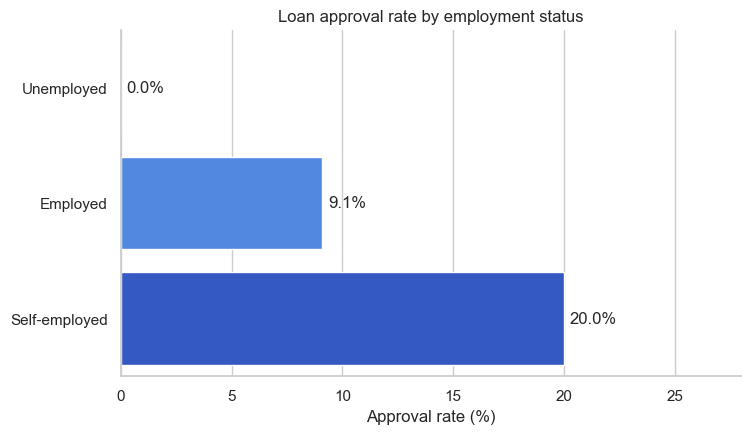

In [21]:
colors = ["#93C5FD", "#3B82F6", "#1D4ED8"]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=approval_summary, x="Approval Rate", y="Employment_Status",
            hue="Employment_Status", palette=colors, legend=False, ax=ax)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set(title="Loan approval rate by employment status", xlabel="Approval rate (%)", ylabel="")
ax.set_xlim(0, approval_summary["Approval Rate"].max() + 8)
sns.despine()
plt.show()

## My lessons learned checks and recap

- DataFrames can be created directly or loaded from CSV and Excel files.
- File options such as `header`, `names`, `sheet_name` and `skiprows` solve common import problems.
- Cleaning is easier when missing values and data types are handled before analysis.
- Dates should use pandas' datetime type before filtering or grouping by time.
